In [94]:
import pandas as pd


In [95]:
df = pd.read_csv('/content/bodyPerformance.csv')

In [96]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [97]:
correlations = df.drop(['gender', 'class'], axis=1).corr()

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: >

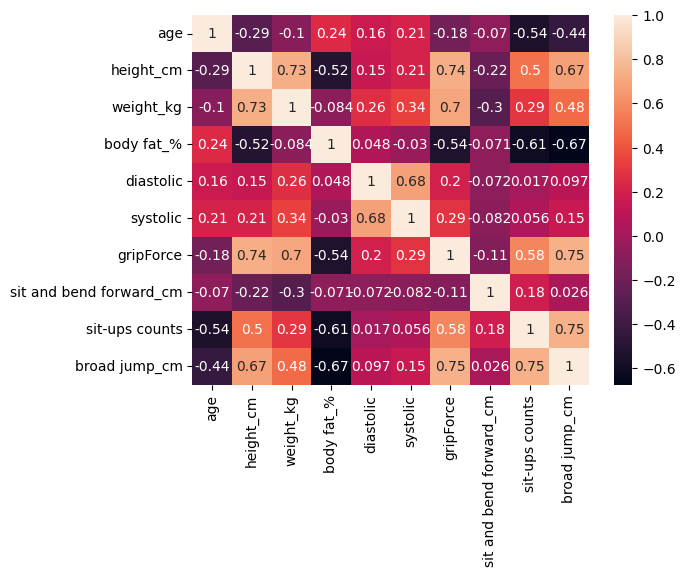

In [99]:
sns.heatmap(correlations, annot=True)

In [100]:
model_data = df[['body fat_%', 'broad jump_cm', 'sit-ups counts']]

In [101]:
model_data.head()

,body fat_%,broad jump_cm,sit-ups counts
0,21.3,217.0,60.0
1,15.7,229.0,53.0
2,20.1,181.0,49.0
3,18.4,219.0,53.0
4,17.1,217.0,45.0


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score

In [103]:
X = model_data.drop('sit-ups counts', axis=1)
Y = model_data['body fat_%']

In [104]:
x_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state= 42)

In [105]:
model = LinearRegression()

In [106]:
model.fit(x_train, Y_train)

LinearRegression()

In [107]:
predictions = model.predict(X_test)

In [108]:
print(mean_absolute_error(Y_test, predictions))

3.0796152820434726e-15


In [109]:
print(mean_squared_error(Y_test,predictions))

1.900127112840861e-29


In [110]:
print(r2_score(Y_test,predictions))

1.0


In [111]:
import matplotlib.pyplot as plt


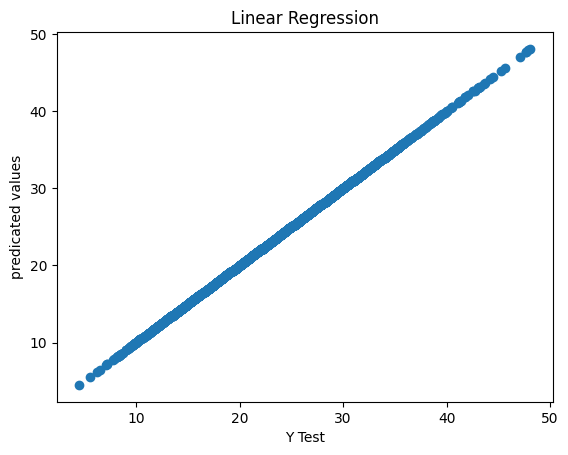

In [112]:
plt.scatter(Y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('predicated values')
plt.title('Linear Regression')
plt.show()